# Principal Component Analysis - Breast Cancer Dimensionality Reduction

## Project Overview

This project applies **Principal Component Analysis (PCA)** to the Breast Cancer Wisconsin (Diagnostic) dataset to reduce the dimensionality of 30 numerical diagnostic features.

The project examines how much variance can be preserved with fewer principal components, visualizes malignant and benign observations in PCA space, analyzes component loadings, and compares Logistic Regression performance before and after PCA.

The main objective is to determine whether PCA can substantially reduce the feature space while retaining most of the dataset's information and maintaining strong classification performance.


## 1. Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 2. Load Dataset


In [2]:
df = pd.read_csv("breast_cancer.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 3. Explore Dataset


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

print("\nDiagnosis distribution:")
print(df["diagnosis"].value_counts())


Columns:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Data types:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimen

## 4. Missing Values and Duplicates


In [4]:
missing = df.isnull().sum().sort_values(ascending=False)

print("Missing values:")
display(missing[missing > 0].to_frame("Missing Count"))

print("\nDuplicate rows:", df.duplicated().sum())


Missing values:


,Missing Count
Unnamed: 32,569



Duplicate rows: 0


## 5. Data Cleaning


In [5]:
# Remove the empty column included in the downloaded CSV, if present
df = df.drop(columns=["Unnamed: 32"], errors="ignore")

# ID is an identifier and should not be used as a predictive/PCA feature
df = df.drop(columns=["id"], errors="ignore")

# Remove exact duplicate rows
df = df.drop_duplicates().copy()

print("Dataset shape after cleaning:", df.shape)
display(df.head())


Dataset shape after cleaning: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 6. Exploratory Data Analysis


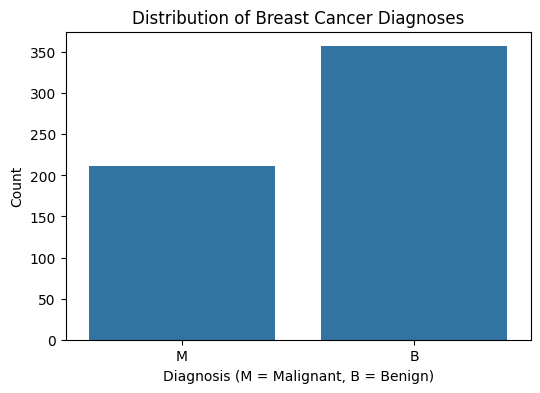

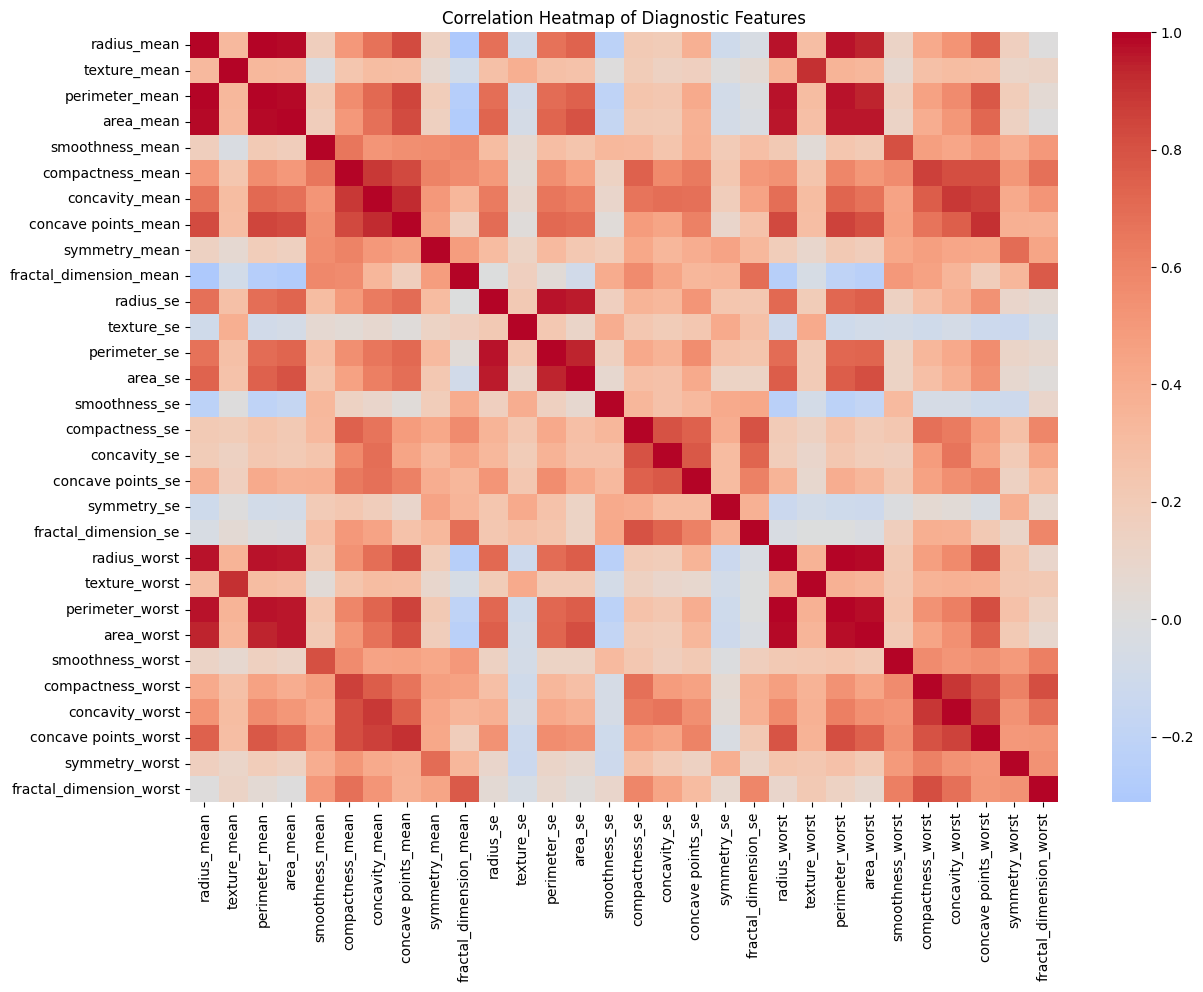

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diagnosis")
plt.title("Distribution of Breast Cancer Diagnoses")
plt.xlabel("Diagnosis (M = Malignant, B = Benign)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(df.drop(columns="diagnosis").corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Diagnostic Features")
plt.show()


## 7. Prepare Features and Target


In [7]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of original features:", X.shape[1])


Feature matrix shape: (569, 30)
Target shape: (569,)
Number of original features: 30


## 8. Standardize Features

PCA is sensitive to feature scale because it identifies directions of maximum variance. The diagnostic variables use different units and ranges, so the features are standardized to mean 0 and standard deviation 1 before applying PCA.


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)
print("Approximate mean after scaling:", np.mean(X_scaled))
print("Approximate standard deviation after scaling:", np.std(X_scaled))


Scaled feature matrix shape: (569, 30)
Approximate mean after scaling: -6.53516165871914e-17
Approximate standard deviation after scaling: 1.0


## 9. Apply PCA to All Components


In [9]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

variance_df = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance Ratio": explained_variance,
    "Cumulative Explained Variance": cumulative_variance
})

display(variance_df)


,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.442720,0.442720
1,PC2,0.189712,0.632432
2,PC3,0.093932,0.726364
3,PC4,0.066021,0.792385
4,PC5,0.054958,0.847343
5,PC6,0.040245,0.887588
6,PC7,0.022507,0.910095
7,PC8,0.015887,0.925983
8,PC9,0.013896,0.939879
9,PC10,0.011690,0.951569


## 10. Explained Variance Analysis


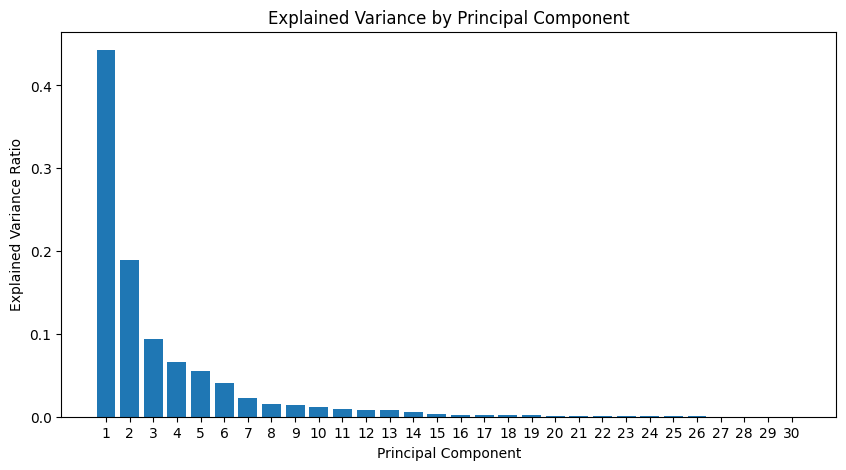

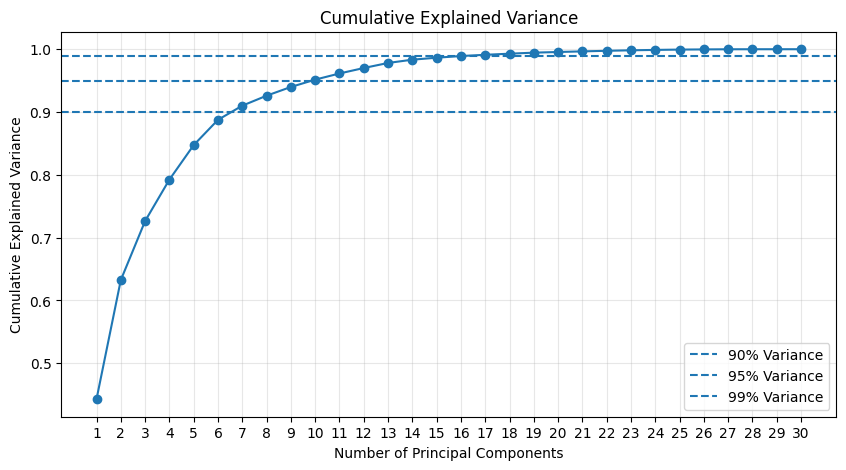

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_variance) + 1), explained_variance)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Component")
plt.xticks(range(1, len(explained_variance) + 1))
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.90, linestyle="--", label="90% Variance")
plt.axhline(y=0.95, linestyle="--", label="95% Variance")
plt.axhline(y=0.99, linestyle="--", label="99% Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 11. Components Required for Target Variance


In [11]:
components_90 = np.argmax(cumulative_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1
components_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"Components required for 90% variance: {components_90}")
print(f"Components required for 95% variance: {components_95}")
print(f"Components required for 99% variance: {components_99}")

print(f"\nOriginal dimensions: {X.shape[1]}")
print(f"Dimensions at 95% variance: {components_95}")
print(f"Dimensionality reduction at 95% variance: {(1 - components_95 / X.shape[1]) * 100:.2f}%")


Components required for 90% variance: 7
Components required for 95% variance: 10
Components required for 99% variance: 17

Original dimensions: 30
Dimensions at 95% variance: 10
Dimensionality reduction at 95% variance: 66.67%


## 12. Two-Dimensional PCA Visualization


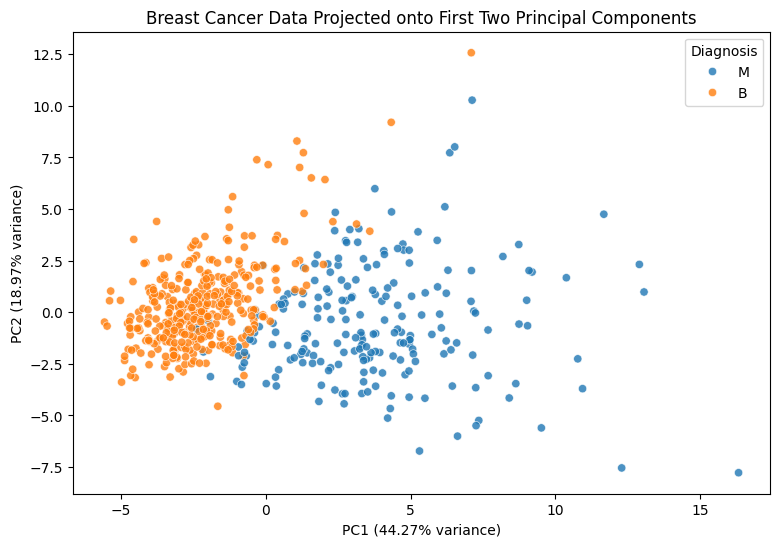

Variance explained by first two components: 63.24%


In [12]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "Diagnosis": y.values
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    alpha=0.8
)
plt.title("Breast Cancer Data Projected onto First Two Principal Components")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.2f}% variance)")
plt.show()

print(
    f"Variance explained by first two components: "
    f"{pca_2d.explained_variance_ratio_.sum() * 100:.2f}%"
)


## 13. Principal Component Loadings


In [13]:
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    index=X.columns,
    columns=["PC1", "PC2"]
)

print("Feature loadings for PC1 and PC2:")
display(loadings)

print("\nTop 10 features contributing to PC1:")
display(loadings["PC1"].abs().sort_values(ascending=False).head(10).to_frame("Absolute Loading"))

print("\nTop 10 features contributing to PC2:")
display(loadings["PC2"].abs().sort_values(ascending=False).head(10).to_frame("Absolute Loading"))


Feature loadings for PC1 and PC2:


,PC1,PC2
radius_mean,0.218902,-0.233857
texture_mean,0.103725,-0.059706
perimeter_mean,0.227537,-0.215181
area_mean,0.220995,-0.231077
smoothness_mean,0.142590,0.186113
compactness_mean,0.239285,0.151892
concavity_mean,0.258400,0.060165
concave points_mean,0.260854,-0.034768
symmetry_mean,0.138167,0.190349
fractal_dimension_mean,0.064363,0.366575



Top 10 features contributing to PC1:


,Absolute Loading
concave points_mean,0.260854
concavity_mean,0.258400
concave points_worst,0.250886
compactness_mean,0.239285
perimeter_worst,0.236640
concavity_worst,0.228768
radius_worst,0.227997
perimeter_mean,0.227537
area_worst,0.224871
area_mean,0.220995



Top 10 features contributing to PC2:


,Absolute Loading
fractal_dimension_mean,0.366575
fractal_dimension_se,0.280092
fractal_dimension_worst,0.275339
radius_mean,0.233857
compactness_se,0.232716
area_mean,0.231077
radius_worst,0.219866
area_worst,0.219352
perimeter_mean,0.215181
smoothness_se,0.204430


## 14. Visualize Principal Component Loadings


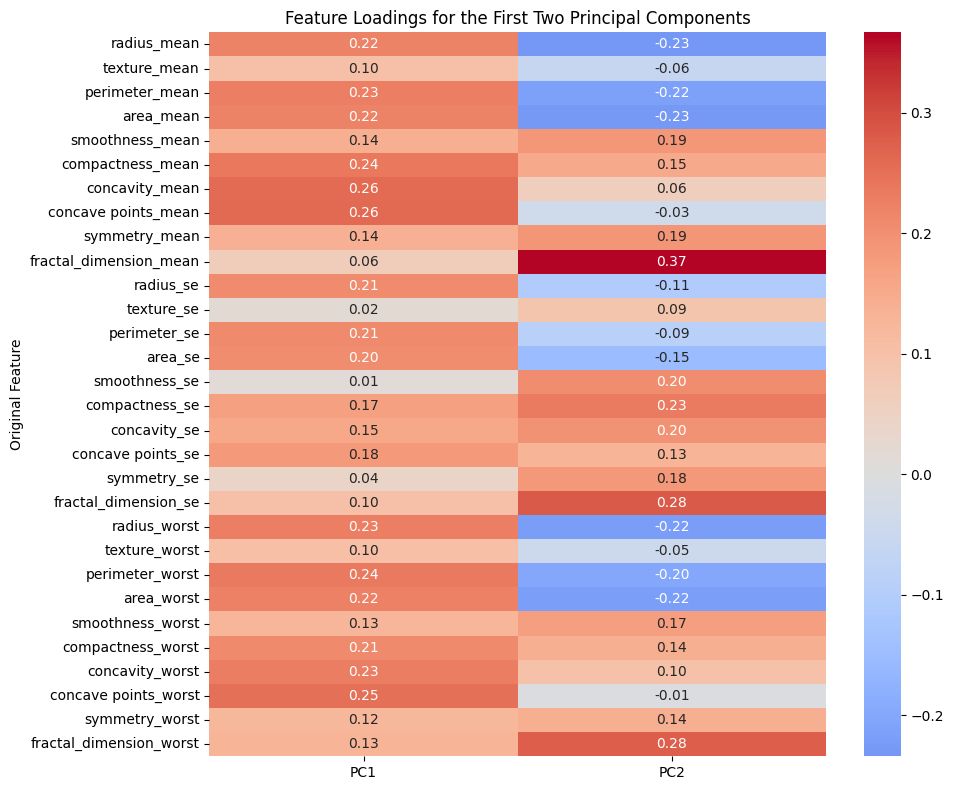

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Loadings for the First Two Principal Components")
ax.set_ylabel("Original Feature")
plt.tight_layout()
plt.show()


## 15. Classification Comparison: Original Features vs PCA

To evaluate whether dimensionality reduction preserves predictive information, Logistic Regression is trained twice:

1. Using all 30 standardized original features.
2. Using only the principal components required to preserve at least 95% of the variance.

The train-test split is performed before fitting the scaler and PCA for this comparison to prevent information from the test set from influencing preprocessing.


### 15.1 Train-Test Split


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (455, 30)
Test set shape: (114, 30)


### 15.2 Logistic Regression Using Original Features


In [16]:
comparison_scaler = StandardScaler()

X_train_scaled = comparison_scaler.fit_transform(X_train)
X_test_scaled = comparison_scaler.transform(X_test)

log_reg_original = LogisticRegression(max_iter=1000, random_state=42)
log_reg_original.fit(X_train_scaled, y_train)

y_pred_original = log_reg_original.predict(X_test_scaled)

original_accuracy = accuracy_score(y_test, y_pred_original)

print(f"Original Features Accuracy: {original_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_original))


Original Features Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

           B       0.96      0.99      0.97        72
           M       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### 15.3 Logistic Regression Using PCA Features


In [17]:
# Fit PCA only on the training data and automatically retain at least 95% variance
pca_95 = PCA(n_components=0.95)
X_train_pca = pca_95.fit_transform(X_train_scaled)
X_test_pca = pca_95.transform(X_test_scaled)

log_reg_pca = LogisticRegression(max_iter=1000, random_state=42)
log_reg_pca.fit(X_train_pca, y_train)

y_pred_pca = log_reg_pca.predict(X_test_pca)

pca_accuracy = accuracy_score(y_test, y_pred_pca)

print("Number of PCA components retained:", pca_95.n_components_)
print(f"Variance retained: {pca_95.explained_variance_ratio_.sum() * 100:.2f}%")
print(f"PCA Features Accuracy: {pca_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca))


Number of PCA components retained: 10
Variance retained: 95.21%
PCA Features Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## 16. Model Performance Comparison


,Model,Number of Features,Accuracy
0,Logistic Regression - Original Features,30,0.964912
1,Logistic Regression - PCA Features,10,0.973684


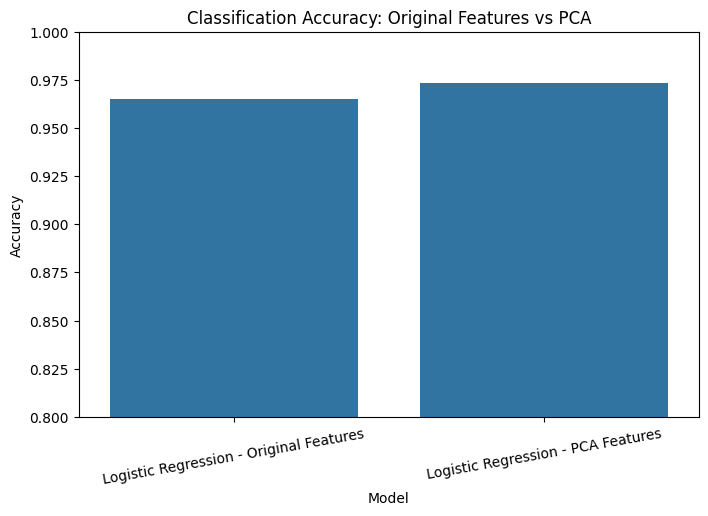

In [18]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression - Original Features",
              "Logistic Regression - PCA Features"],
    "Number of Features": [X.shape[1], pca_95.n_components_],
    "Accuracy": [original_accuracy, pca_accuracy]
})

display(comparison_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Model", y="Accuracy")
plt.ylim(0.8, 1.0)
plt.title("Classification Accuracy: Original Features vs PCA")
plt.xticks(rotation=10)
plt.show()


## 17. Confusion Matrices


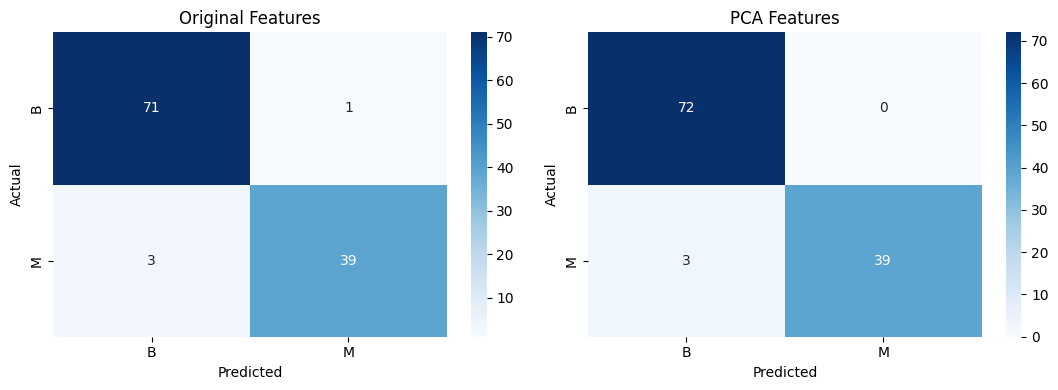

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_original),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=log_reg_original.classes_,
    yticklabels=log_reg_original.classes_,
    ax=axes[0]
)
axes[0].set_title("Original Features")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    confusion_matrix(y_test, y_pred_pca),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=log_reg_pca.classes_,
    yticklabels=log_reg_pca.classes_,
    ax=axes[1]
)
axes[1].set_title("PCA Features")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 18. Key Findings

- The dataset contained **569 observations** and **30 numerical diagnostic features** after removing the identifier column and the completely empty `Unnamed: 32` column.
- No duplicate rows were found in the dataset.
- PCA showed that only **7 principal components** were required to preserve at least **90%** of the total variance.
- **10 principal components** preserved at least **95%** of the variance, while **17 components** were required to preserve at least **99%**.
- Reducing the feature space from **30 original features to 10 principal components** while retaining approximately **95.21% of the variance** resulted in a **66.67% reduction in dimensionality**.
- The first two principal components alone explained approximately **63.24%** of the total variance and provided a useful two-dimensional representation of the dataset.
- PC1 was influenced most strongly by features related to **concave points, concavity, compactness, perimeter, radius, and area**, indicating that correlated tumor size and shape characteristics contribute strongly to the dominant direction of variation.
- PC2 was influenced most strongly by **fractal-dimension features**, along with several size and compactness-related measurements.
- Logistic Regression using all **30 standardized original features** achieved an accuracy of **96.49%**.
- Logistic Regression using only the **10 PCA components** retaining approximately 95% of the variance achieved a slightly higher accuracy of **97.37%**.
- The PCA-based model therefore reduced the number of input dimensions by two-thirds while maintaining—and in this experiment slightly improving—classification performance.

## 19. Conclusion

This project demonstrated how **Principal Component Analysis (PCA)** can reduce the dimensionality of the Breast Cancer Wisconsin Diagnostic dataset while preserving most of its underlying information.

After standardizing the 30 numerical diagnostic features, PCA showed that only **10 principal components** were needed to retain approximately **95.21% of the total variance**. This reduced the feature space from 30 dimensions to 10, corresponding to a **66.67% reduction in dimensionality**. The first two principal components alone captured approximately **63.24% of the variance**, allowing the high-dimensional dataset to be represented and explored in two dimensions.

The component-loading analysis showed that the principal components combine information from multiple correlated tumor measurements rather than representing individual original variables. Features related to concavity, concave points, compactness, tumor size, and fractal dimension contributed substantially to the first two components.

The classification comparison further demonstrated that dimensionality reduction did not harm predictive performance. Logistic Regression achieved **96.49% accuracy** using all 30 original standardized features, compared with **97.37% accuracy** using only the 10 PCA components.

Overall, the results show that PCA successfully compressed the dataset while retaining its important structure and predictive information. In this experiment, PCA produced a substantially smaller feature representation with comparable—and slightly improved—classification accuracy, demonstrating its usefulness for dimensionality reduction, visualization, and handling correlated high-dimensional features.